2026-07-14 18:09:02.742 | INFO     | __main__:model_call_evaluator:67 - grade='好笑' feedback=''
2026-07-14 18:09:06.712 | INFO     | __main__:model_call_evaluator:67 - grade='不好笑' feedback='这个笑话的谐音梗比较常见（“喵”谐音“没”），属于比较老套的网络段子类型。而且笑点过于直白，在讲出“喵事”时观众基本能猜到后面的转折，缺乏惊喜感。建议可以加入更多铺垫或反转，比如让猫真的买了点东西，或者店员有其他有趣的反应来增加趣味性。'
2026-07-14 18:09:10.998 | INFO     | __main__:<module>:111 - 超步数量达到最大限制


一只猫去应聘工作，面试官问：“你有什么特长？”  
猫自信地说：“我会抓老鼠、会卖萌，还会计算数学题。”  
面试官惊讶：“数学题？那你算算2+2等于几？”  
猫想了想，回答：“等于鱼。”  
面试官：“不对，等于4。”  
猫淡定地说：“可我觉得，鱼比4更美味。”


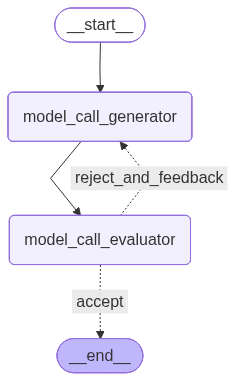

In [5]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from loguru import logger
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 图状态
class OverAllState(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

# 定义用于结构化输出的 Schema，作为笑话评估依据
class Feedback(BaseModel):
    grade: Literal["好笑", "不好笑"] = Field(
        description="判断这个笑话是否好笑。",
    )
    feedback: str = Field(
        description="如果笑话不好笑，请给出具体的改进建议。",
    )

# 为大模型添加结构化输出能力，定义评估器
evaluator = model.with_structured_output(Feedback)

# 节点
def model_call_generator(state: OverAllState) -> OverAllState:
    """大模型生成笑话"""

    if state.get("feedback"):
        msg = model.invoke(
            f"""
            写一个关于“{state['topic']}”的笑话。

            请参考下面的改进建议：
            {state['feedback']}
            """
        )
    else:
        msg = model.invoke(f"写一个关于“{state['topic']}”的笑话")

    return {"joke": msg.content}


def model_call_evaluator(state: OverAllState) -> OverAllState:
    """大模型评估笑话"""

    grade = evaluator.invoke(
        f"""
        请评估下面这个笑话是否好笑：

        {state['joke']}
        """
    )
    logger.info(grade)
    return {
        "funny_or_not":grade,
        "feedback": grade.feedback,
    }


# 条件边函数：根据评估结果决定结束流程，或者返回笑话生成节点
def route_joke(state: OverAllState) -> Literal["accept", "reject_and_feedback", END]:
    """根据评估结果决定接受笑话或根据反馈重新生成"""

    if state["funny_or_not"] == "好笑":
        return "accept"
    elif state["funny_or_not"] == "不好笑":
        return "reject_and_feedback"
    return END

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("model_call_generator", model_call_generator)
builder.add_node("model_call_evaluator", model_call_evaluator)

# 添加边，连接各个节点
builder.add_edge(START, "model_call_generator")
builder.add_edge("model_call_generator", "model_call_evaluator")
builder.add_conditional_edges(
    "model_call_evaluator",
    route_joke,
    {
        # route_joke 返回的名称：接下来要执行的节点
        "accept": END,
        "reject_and_feedback": "model_call_generator",
    },
)

# 编译工作流
graph = builder.compile()

# 调用工作流
try:
    state = graph.invoke({"topic": "猫"},config={"recursion_limit":5})
except Exception as e:
    logger.info("超步数量达到最大限制")

print(state["joke"])

# 显示工作流图
from IPython.display import display
display(graph)